In [ ]:
# Notebook 09: SHAP Explainability for Diabetes Prediction

## MSc Data Science and Analytics

### Explainable Machine Learning versus Deep Learning for Early Disease Prediction: A Multi-Dataset Comparative Study

This notebook applies SHAP (SHapley Additive exPlanations) to interpret the best-performing machine learning model developed for the
Pima Indians Diabetes dataset. SHAP provides both global and local explanations of model predictions,
improving transparency and supporting clinical interpretation.

In [ ]:
## Objectives

The objectives of this notebook are to:

- Load the trained Random Forest model.
- Load the processed diabetes dataset.
- Generate SHAP explanations.
- Visualise global feature importance.
- Explain individual predictions.
- Save all SHAP visualisations.

In [1]:
from pathlib import Path

import joblib
import shap

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "diabetes"

MODELS_PATH = PROJECT_ROOT / "models"

FIGURES_PATH = PROJECT_ROOT / "Figures"

FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(
    RAW_PATH / "diabetes.csv.csv"
)

In [4]:
columns_with_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_with_missing] = df[columns_with_missing].replace(0, np.nan)

In [5]:
imputer = joblib.load(
    MODELS_PATH / "diabetes_imputer.pkl"
)

df[columns_with_missing] = imputer.transform(
    df[columns_with_missing]
)

In [6]:
X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]

In [7]:
rf = joblib.load(
    MODELS_PATH / "diabetes_random_forest.pkl"
)

In [8]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X)

In [9]:
type(shap_values)

numpy.ndarray

In [10]:
print(np.array(shap_values).shape)

(768, 8, 2)


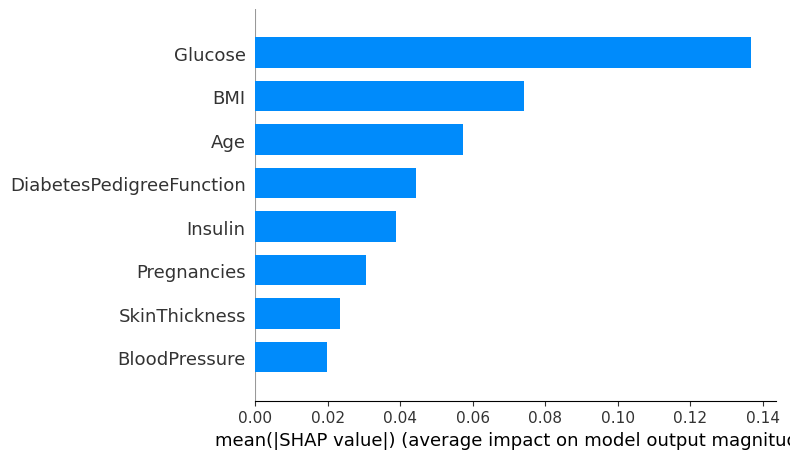

In [11]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "diabetes_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

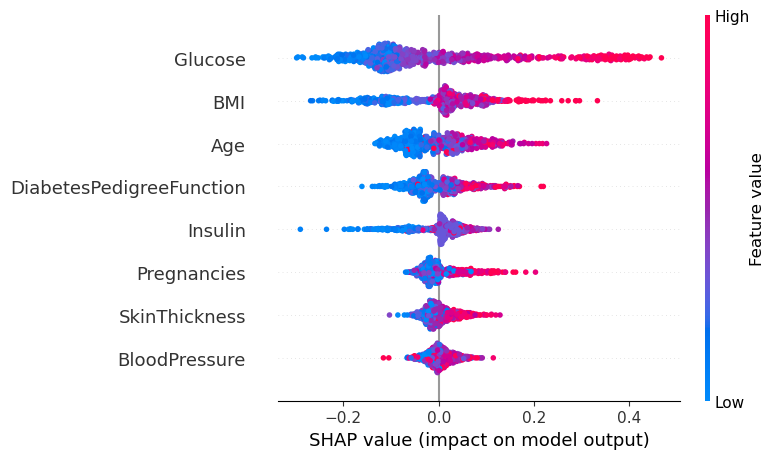

In [12]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "diabetes_shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

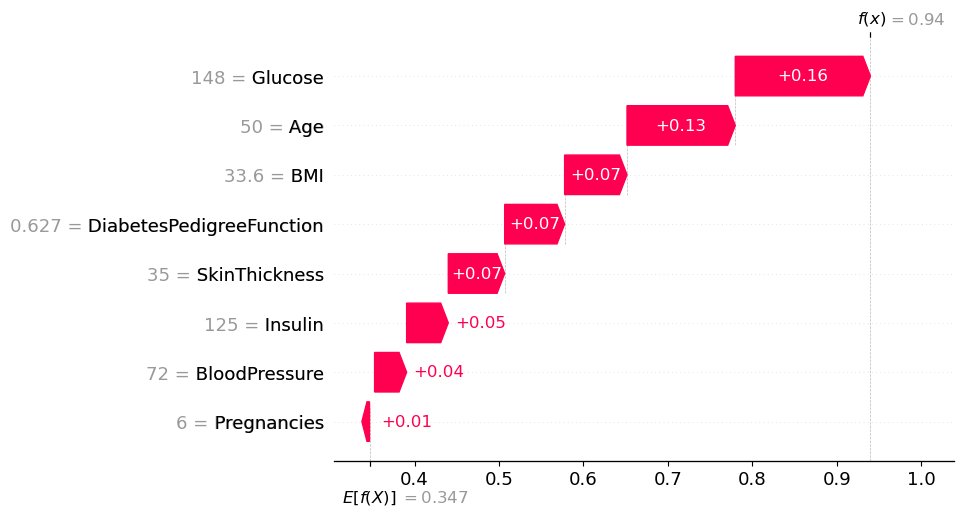

In [13]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X.iloc[0],
        feature_names=X.columns
    ),
    show=False
)

plt.savefig(
    FIGURES_PATH / "diabetes_shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Interpretation

SHAP analysis provides insight into the clinical variables that most strongly influence the Random Forest model's predictions.

The SHAP feature importance plot ranks predictors according to their overall contribution to model output,
while the SHAP summary plot illustrates both the magnitude and direction of each feature's influence across all patients.

The waterfall plot explains an individual prediction by showing how each feature contributes to increasing or decreasing
the predicted probability of diabetes. These visualisations enhance the transparency and interpretability of the machine learning model,
supporting its potential application in clinical decision-making.

In [ ]:
# Conclusion

This notebook applied SHAP explainability to the best-performing Random Forest model developed for the Pima Indians Diabetes dataset.

The analysis identified the most influential clinical predictors and provided both global and local explanations of model behaviour.
These findings improve model transparency and support trustworthy interpretation of machine learning predictions in a healthcare setting.

The next stage of the project will extend the same methodology to the Breast Cancer dataset before conducting a
comprehensive comparison across all three clinical datasets.